In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [94]:
df = pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [95]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (101766, 50)

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [97]:
df.isnull().sum()[df.isnull().sum() > 0]

max_glu_serum    96420
A1Cresult        84748
dtype: int64

In [98]:
(df == "?").sum()[(df == "?").sum()>0]

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64

Datasetdə bəzi missing values `NaN` kimi deyil, `"?"` simvolu ilə saxlanılıb. Buna görə həm real null values, həm də `"?"` kimi kodlaşdırılmış missing values ayrıca yoxlanıldı.

In [99]:
missing = (df == "?").sum()

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent.round(2)
})

missing_table = missing_table[missing_table["Missing Count"] > 0]
missing_table.sort_values("Missing Percent", ascending=False)

,Missing Count,Missing Percent
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


Missing values sütunlar üzrə bərabər paylanmayıb. `weight` sütununda təxminən 97%, `medical_specialty` sütununda təxminən 49% və `payer_code` sütununda təxminən 40% missing value mövcuddur. Diaqnoz və `race` sütunlarında isə missing values daha azdır.

Bu nəticələr preprocessing mərhələsində nəzərə alındı. Çox yüksək missing faizinə malik sütunlar güclü imputasiya fərziyyələri tələb etdiyi üçün modeldən çıxarıldı.

In [100]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [101]:
df["readmitted"].value_counts(normalize=True) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

In [102]:
df1 = pd.read_csv("IDS_mapping.csv")

In [103]:
df1

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


In [104]:
df["early_readmission"] = (df["readmitted"] == "<30").astype(int)

Original `readmitted` variable üç kateqoriyadan ibarətdir. Binary classification qurmaq üçün `<30` kateqoriyası `1` olaraq, `>30` və `NO` kateqoriyaları isə `0` olaraq kodlaşdırıldı. Beləliklə, `1` early readmission hadisəsini, `0` isə early readmission olmayan halları göstərir.

In [105]:
df["early_readmission"].value_counts()

early_readmission
0    90409
1    11357
Name: count, dtype: int64

Positive class (`1`) minority class-dır. Buna görə sonrakı model qurulmasında class imbalance nəzərə alınacaq.

In [106]:
df["patient_nbr"].nunique() == len(df)

False

In [107]:
df["patient_nbr"].value_counts().head(10)

patient_nbr
88785891    40
43140906    28
1660293     23
23199021    23
88227540    23
23643405    22
84428613    22
92709351    21
90609804    20
89472402    20
Name: count, dtype: int64


`patient_nbr` sütununun unique dəyərlərinin sayı encounter sayından azdır. Bu göstərir ki, datasetdə eyni xəstəyə aid bir neçə encounter mövcuddur.
Bu struktur train və test setlərinə eyni xəstənin düşməsi riskini yaradır. Buna görə model qiymətləndirilərkən patient-level split istifadə ediləcək.

In [108]:
df.nunique().sort_values()

citoglipton                      1
examide                          1
acetohexamide                    2
glipizide-metformin              2
tolbutamide                      2
early_readmission                2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
metformin-pioglitazone           2
troglitazone                     2
diabetesMed                      2
change                           2
tolazamide                       3
gender                           3
max_glu_serum                    3
A1Cresult                        3
readmitted                       3
acarbose                         4
miglitol                         4
rosiglitazone                    4
glimepiride                      4
metformin                        4
nateglinide                      4
repaglinide                      4
chlorpropamide                   4
glipizide                        4
glyburide                        4
insulin                          4
glyburide-metformin 

In [109]:
df["encounter_id"].nunique() == len(df)

True

In [110]:
df = df.drop(columns=["weight", "medical_specialty", "payer_code"])

`weight`, `medical_specialty` və `payer_code` sütunlarında çox yüksək missing rate müşahidə edildi. Bu sütunları güclü fərziyyələrlə doldurmaq əvəzinə modeldən çıxarmaq seçildi. Bu yanaşma süni şəkildə məlumat yaratmaq riskini azaltmağa kömək edir.

In [111]:
X = df.drop(columns=["early_readmission", "readmitted"])
y = df["early_readmission"]

In [112]:
groups = df["patient_nbr"]

In [113]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

Adi random split əvəzinə `GroupShuffleSplit` istifadə edildi. Burada `patient_nbr` group kimi verilir ki, eyni xəstənin encounter-ləri həm training, həm də test setinə düşməsin.

Datasetin 80%-i training, 20%-i isə test üçün ayrıldı.

In [114]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [115]:
 len(set(X_train['patient_nbr']) & set(X_test['patient_nbr']))

0

Training və test setləri arasında ortaq `patient_nbr` dəyərləri yoxlanıldı. Nəticənin `0` olması eyni xəstənin hər iki setdə olmadığını göstərir və patient-level leakage riskinin qarşısının alındığını təsdiqləyir.

In [116]:
X_train.drop(['patient_nbr', 'encounter_id'], axis=1, inplace=True)

In [117]:
X_test.drop(['patient_nbr', 'encounter_id'], axis=1, inplace=True)

`patient_nbr` və `encounter_id` identifikator sütunlarıdır və model üçün faydalı predictive feature hesab edilmir. `patient_nbr` patient-level train/test split üçün istifadə edildikdən sonra, hər iki ID sütunu model feature-lərindən çıxarıldı.

In [118]:
X_train = X_train.replace("?", np.nan)
X_test = X_test.replace("?", np.nan)

Datasetdə bəzi missing values `NaN` əvəzinə `"?"` simvolu ilə göstərilmişdi. Bu dəyərlər `NaN` ilə əvəz edilərək sonrakı preprocessing mərhələsində missing values kimi düzgün şəkildə işlənməsi təmin edildi.

In [119]:
X_train.isnull().sum()[X_train.isnull().sum()>0]

race              1863
diag_1              14
diag_2             294
diag_3            1138
max_glu_serum    77260
A1Cresult        67938
dtype: int64

In [120]:
X_train.dtypes

race                          str
gender                        str
age                           str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide                 str
glipizide                     str
glyburide                     str
tolbutamide                   str
pioglitazone                  str
rosiglitazone 

In [121]:
X_train[[
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]].nunique()

admission_type_id            8
discharge_disposition_id    26
admission_source_id         17
dtype: int64

In [122]:
categorical_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
categorical_cols

['race',
 'gender',
 'age',
 'diag_1',
 'diag_2',
 'diag_3',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed']

In [123]:
categorical_cols += [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

Datasetdə mətn tipində olan sütunlar categorical feature kimi müəyyən edildi. Bundan əlavə, `admission_type_id`, `discharge_disposition_id` və `admission_source_id` rəqəmlərlə kodlaşdırılsa da, əslində kateqoriyaları ifadə etdiyi üçün categorical feature kimi nəzərə alındı.

In [124]:
numerical_cols = X_train.select_dtypes(include="number").columns.tolist()
numerical_cols

['admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses']

In [125]:
numerical_cols = [
    col for col in numerical_cols
    if col not in categorical_cols
]

In [126]:
numerical_cols

['time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses']

Rəqəmsal tipdə olan sütunlar numerical feature kimi müəyyən edildi. Lakin admission, discharge və admission source ID-ləri rəqəm formasında olmasına baxmayaraq categorical olduğu üçün numerical feature siyahısından çıxarıldı.

In [127]:
X_train[categorical_cols].isnull().sum()[X_train[categorical_cols].isnull().sum()>0]

race              1863
diag_1              14
diag_2             294
diag_3            1138
max_glu_serum    77260
A1Cresult        67938
dtype: int64

In [128]:
X_train['race'] = X_train['race'].fillna(X_train['race'].mode()[0])

In [129]:
X_train['race'].isnull().sum()

np.int64(0)

In [130]:
X_train['diag_1'] = X_train['diag_1'].fillna(X_train['diag_1'].mode()[0])

In [131]:
X_train['diag_2'] = X_train['diag_2'].fillna(X_train['diag_2'].mode()[0])

In [132]:
X_train['diag_3'] = X_train['diag_3'].fillna(X_train['diag_3'].mode()[0])

`race`, `diag_1`, `diag_2` və `diag_3` sütunlarında olan missing values train datasetində ən çox təkrarlanan kateqoriya (`mode`) ilə əvəz edildi.

In [133]:
X_test["race"] = X_test["race"].fillna(X_train["race"].mode()[0])
X_test["diag_1"] = X_test["diag_1"].fillna(X_train["diag_1"].mode()[0])
X_test["diag_2"] = X_test["diag_2"].fillna(X_train["diag_2"].mode()[0])
X_test["diag_3"] = X_test["diag_3"].fillna(X_train["diag_3"].mode()[0])

Test datasetində missing values doldurularkən train datasetindən hesablanmış `mode` dəyərlərindən istifadə edildi. Bu yanaşma test məlumatından preprocessing zamanı məlumat sızmasının (`data leakage`) qarşısını almağa kömək edir.

In [134]:
X_train["max_glu_serum"] = X_train["max_glu_serum"].fillna("Missing")
X_train["A1Cresult"] = X_train["A1Cresult"].fillna("Missing")

X_test["max_glu_serum"] = X_test["max_glu_serum"].fillna("Missing")
X_test["A1Cresult"] = X_test["A1Cresult"].fillna("Missing")

`max_glu_serum` və `A1Cresult` sütunlarında missing values çox olduğu üçün onları mode ilə doldurmaq əvəzinə ayrıca `"Missing"` kateqoriyası yaradıldı. Beləliklə, analiz nəticəsinin mövcud olmaması ayrıca məlumat kimi saxlanıldı.

In [135]:
X_train[categorical_cols].isnull().sum()

race                        0
gender                      0
age                         0
diag_1                      0
diag_2                      0
diag_3                      0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide                     0
citoglipton                 0
insulin                     0
glyburide-metformin         0
glipizide-metformin         0
glimepiride-pioglitazone    0
metformin-rosiglitazone     0
metformin-pioglitazone      0
change                      0
diabetesMed                 0
admission_

In [136]:
X_test[categorical_cols].isnull().sum()

race                        0
gender                      0
age                         0
diag_1                      0
diag_2                      0
diag_3                      0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide                     0
citoglipton                 0
insulin                     0
glyburide-metformin         0
glipizide-metformin         0
glimepiride-pioglitazone    0
metformin-rosiglitazone     0
metformin-pioglitazone      0
change                      0
diabetesMed                 0
admission_

In [139]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [141]:
preprocessor = ColumnTransformer (
    transformers = [
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ])

In [142]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

### Encoding Categorical Features

Modelə categorical məlumatları birbaşa vermək mümkün olmadığı üçün `OneHotEncoder` istifadə edildi. Categorical sütunlar ayrı-ayrı binary sütunlara çevrildi.

`ColumnTransformer` vasitəsilə categorical sütunlara One-Hot Encoding tətbiq edildi, numerical sütunlar isə dəyişdirilmədən saxlanıldı.

Preprocessor yalnız train datasetində `fit` edildi və test datasetinə həmin öyrənilmiş çevirmə tətbiq edildi. `handle_unknown="ignore"` test datasetində train zamanı görülməyən kateqoriyaların xəta yaratmasının qarşısını alır.

In [143]:
X_train_encoded.shape

(81613, 2330)

In [144]:
X_test_encoded.shape

(20153, 2330)

In [145]:
from sklearn.linear_model import LogisticRegression

In [146]:
lr_model = LogisticRegression( max_iter=1000, class_weight="balanced")
lr_model.fit(X_train_encoded, y_train)

C:\Users\LENOVO\Desktop\Mini_Foresight\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

### Logistic Regression Baseline

İlk model kimi Logistic Regression baseline modelindən istifadə edildi. `class_weight="balanced"` seçimi target-dəki class imbalance problemini nəzərə almaq üçün istifadə olunur. `max_iter=1000` isə modelin öyrənməsi üçün maksimum iterasiya sayını artırır.

In [148]:
y_pred_lr = lr_model.predict(X_test_encoded)
y_prob_lr = lr_model.predict_proba(X_test_encoded)[:,1]

In [149]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78     18002
           1       0.17      0.55      0.25      2151

    accuracy                           0.66     20153
   macro avg       0.55      0.61      0.52     20153
weighted avg       0.84      0.66      0.72     20153



In [151]:
from sklearn.metrics import ( roc_auc_score, average_precision_score )
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("PR-AUC:", average_precision_score(y_test, y_prob_lr))

ROC-AUC: 0.6592275428253207
PR-AUC: 0.2026834453136518


Logistic Regression modelinin performansı classification report, ROC-AUC və PR-AUC metrikləri ilə qiymətləndirildi. PR-AUC xüsusilə class imbalance olan datasetlərdə positive class üzrə precision və recall arasındakı performansı qiymətləndirmək üçün istifadə edildi.

In [152]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

7.865196610905931


### Handling Class Imbalance for XGBoost

Train datasetində `0` sinfi `1` sinfindən daha çox olduğu üçün class imbalance mövcuddur. `scale_pos_weight` negative və positive class nümunələrinin sayına əsasən hesablanaraq XGBoost modelində positive class üçün daha yüksək çəki vermək məqsədilə istifadə edildi.

In [163]:
from xgboost import XGBClassifier

In [164]:
groups_train = df.loc[X_train.index, "patient_nbr"]

In [165]:
from sklearn.model_selection import GroupKFold

group_cv = GroupKFold(n_splits=3)

Model tuning zamanı patient-level leakage-in qarşısını almaq üçün `GroupKFold` istifadə edildi. `n_splits=3` train datasetinin 3 fold-a bölünməsi və modelin hər fold-u növbə ilə validation kimi istifadə etməsi deməkdir. `patient_nbr` qrupları qorunduğu üçün eyni xəstənin məlumatları fərqli fold-lara bölünmür.

In [168]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "scale_pos_weight": [5, 7.865, 10]
}

### XGBoost Hyperparameter Tuning

XGBoost modelinin parametrlərini əl ilə seçmək əvəzinə müxtəlif parameter kombinasiyaları yoxlanıldı. 

In [169]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=group_cv,
    random_state=42,
    n_jobs=-1
)


`RandomizedSearchCV` verilmiş hyperparameter-lər arasından 20 fərqli kombinasiya seçərək modelləri yoxlayır. Hər kombinasiya 3-fold patient-level cross-validation ilə qiymətləndirilir.  Model seçimində `average_precision` istifadə edildi, çünki target dəyişənində class imbalance mövcuddur.

In [170]:
random_search.fit( X_train_encoded, y_train, groups=groups_train )

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKFold(n_...shuffle=False)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly

In [171]:
print(random_search.best_score_)
print(random_search.best_params_)

0.22545138797366196
{'subsample': 0.8, 'scale_pos_weight': 5, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


`best_score_` cross-validation zamanı əldə edilən ən yüksək PR-AUC nəticəsini göstərir. 

In [172]:
best_xgb = random_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test_encoded)
y_prob_xgb = best_xgb.predict_proba(X_test_encoded)[:, 1]

Hyperparameter tuning nəticəsində ən yüksək cross-validation PR-AUC göstərən model `best_estimator_` vasitəsilə seçildi. Bu model artıq optimal hyperparameter-lərlə öyrədilmiş vəziyyətdədir.

In [173]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90     18002
           1       0.24      0.30      0.26      2151

    accuracy                           0.82     20153
   macro avg       0.58      0.59      0.58     20153
weighted avg       0.84      0.82      0.83     20153



In [174]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

ROC-AUC: 0.6743878889225129
PR-AUC: 0.21333444577282493


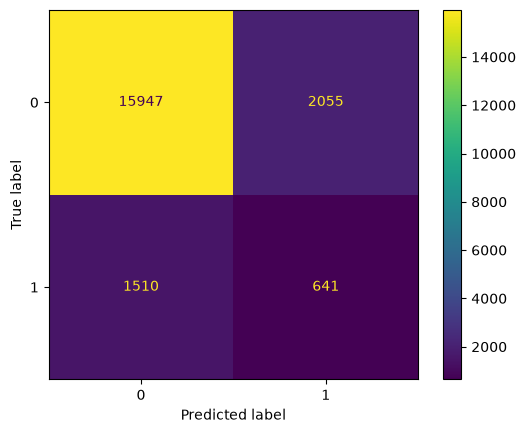

In [175]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [177]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [178]:
thresholds = [0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    print("Threshold:", threshold)
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall:", recall_score(y_test, y_pred_threshold))
    print("F1:", f1_score(y_test, y_pred_threshold))
    print()

Threshold: 0.2
Precision: 0.11314205130986603
Recall: 0.9697814969781497
F1: 0.20264231591218185

Threshold: 0.3
Precision: 0.13877454084863838
Recall: 0.8149697814969782
F1: 0.23716431035649058

Threshold: 0.4
Precision: 0.17619397501836884
Recall: 0.5574151557415156
F1: 0.26775346136668154

Threshold: 0.5
Precision: 0.23775964391691395
Recall: 0.29800092980009296
F1: 0.26449350113472253



### Threshold Analysis

XGBoost modelinin probability nəticələrini 0 və 1 siniflərinə çevirmək üçün müxtəlif classification threshold-ları yoxlanıldı. Daha aşağı threshold daha çox müşahidənin positive class kimi müəyyən edilməsinə səbəb olur və recall-un artmasına, precision-un isə azalmasına gətirib çıxara bilər.

Bu analiz early readmission hallarını aşkar etmək və precision-recall arasındakı trade-off-u qiymətləndirmək üçün aparıldı.

In [179]:
from sklearn.metrics import precision_recall_curve

In [180]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)

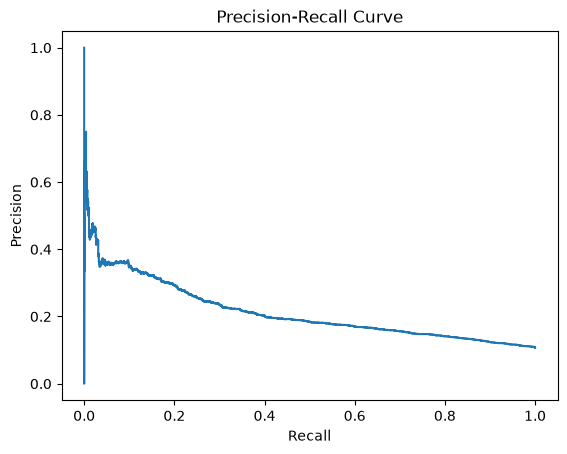

In [181]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [182]:
y_pred_xgb_02 = (y_prob_xgb >= 0.2).astype(int)

In [183]:
print(classification_report(y_test, y_pred_xgb_02))

              precision    recall  f1-score   support

           0       0.96      0.09      0.17     18002
           1       0.11      0.97      0.20      2151

    accuracy                           0.19     20153
   macro avg       0.54      0.53      0.19     20153
weighted avg       0.87      0.19      0.17     20153



In [187]:
import shap

C:\Users\LENOVO\Desktop\Mini_Foresight\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [188]:
explainer = shap.TreeExplainer(best_xgb)

XGBoost modelinin qərarlarını izah etmək üçün SHAP istifadə edildi. `TreeExplainer` ağac əsaslı model üçün hər bir feature-in model prediction-ına təsirini hesablamaq üçün hazırlandı.

In [190]:
shap_values = explainer.shap_values(X_test_encoded)

SHAP values test datasetində hər bir müşahidə və feature üçün həmin feature-in model prediction-ına təsirini göstərir. Müsbət SHAP value prediction-ı `1` sinfinə, mənfi SHAP value isə `0` sinfinə doğru dəyişdirir.

In [192]:
feature_names = preprocessor.get_feature_names_out()

One-Hot Encoding-dən sonra feature-lərin adlarını əldə etmək üçün `preprocessor.get_feature_names_out()` istifadə edildi. Bu adlar SHAP qrafikində real feature adlarını göstərməyə imkan verir.

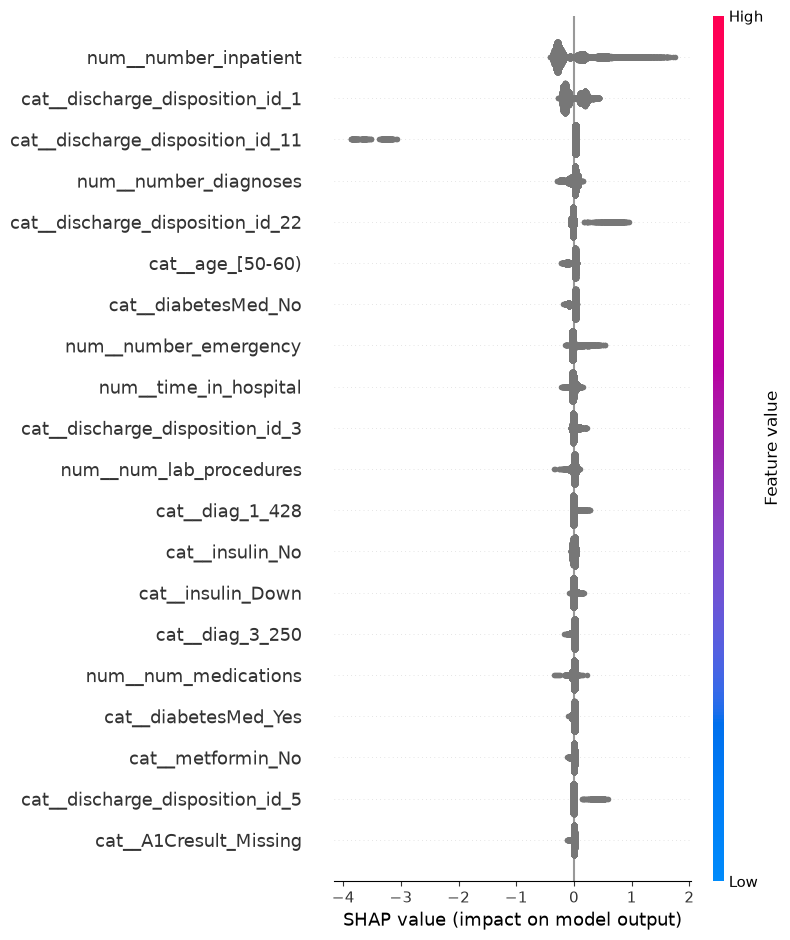

In [193]:
shap.summary_plot(
    shap_values,
    X_test_encoded,
    feature_names=feature_names
)

In [210]:
positive_idx = np.where(y_pred_xgb == 1)[0]

print(positive_idx[:10])

[  7  17  46  48  91  97  98 128 155 166]


In [211]:
patient_idx = positive_idx[0]

In [212]:
patient_idx

np.int64(7)

In [213]:
shap_patient = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=X_test_encoded[patient_idx].toarray().flatten(),
    feature_names=feature_names
)

### Local SHAP Explanation

Model tərəfindən `1` kimi proqnozlaşdırılan bir müşahidə seçildi və həmin müşahidə üçün SHAP explanation hazırlandı. Bu explanation həmin müşahidənin prediction-ına hansı feature-lərin müsbət və ya mənfi təsir etdiyini göstərir.

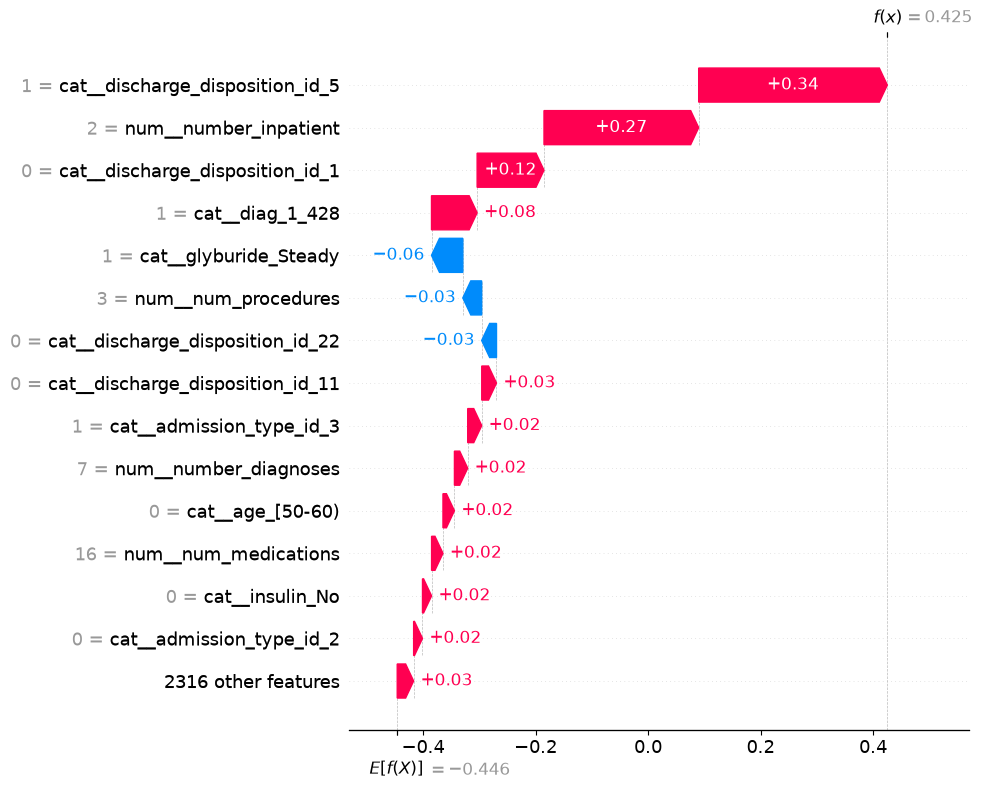

In [214]:
shap.plots.waterfall(shap_patient, max_display=15)

In [215]:
false_negative_idx = np.where(
    (y_test.values == 1) & (y_pred_xgb == 0)
)[0]

print(false_negative_idx[:10])

[  9  29  42  84  92  95 141 145 159 177]


In [216]:
fn_idx = false_negative_idx[0]

print("Index:", fn_idx)
print("Actual:", y_test.iloc[fn_idx])
print("Predicted:", y_pred_xgb[fn_idx])
print("Probability:", y_prob_xgb[fn_idx])

Index: 9
Actual: 1
Predicted: 0
Probability: 0.25029626


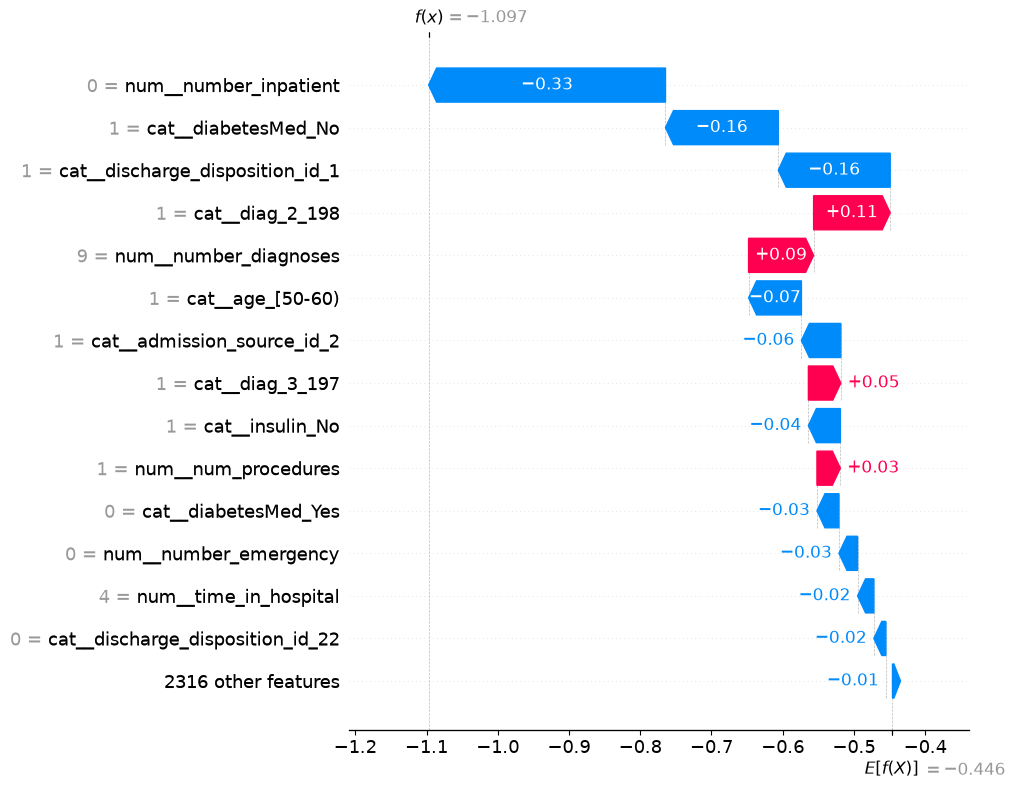

In [217]:
fn_shap_patient = shap.Explanation(
    values=shap_values[fn_idx],
    base_values=explainer.expected_value,
    data=X_test_encoded[fn_idx].toarray().flatten(),
    feature_names=feature_names
)

shap.plots.waterfall(fn_shap_patient, max_display=15)

### SHAP Analysis of a False Negative

Modelin səhvən `0` kimi proqnozlaşdırdığı, lakin əslində `1` olan bir müşahidə seçildi. SHAP waterfall plot vasitəsilə bu səhv prediction-a hansı feature-lərin təsir etdiyi araşdırıldı.

Bu analiz modelin hansı hallarda early readmission riskini düzgün müəyyən edə bilmədiyini anlamağa kömək edir.

In [218]:
shap_importance = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": shap_importance
})

shap_importance_df = shap_importance_df.sort_values(
    "mean_abs_shap",
    ascending=False
)

print(shap_importance_df.head(15))

                               feature  mean_abs_shap
2328             num__number_inpatient       0.294252
2279   cat__discharge_disposition_id_1       0.159091
2289  cat__discharge_disposition_id_11       0.072596
2329             num__number_diagnoses       0.046035
2299  cat__discharge_disposition_id_22       0.036172
13                    cat__age_[50-60)       0.036028
2269               cat__diabetesMed_No       0.034525
2327             num__number_emergency       0.033619
2322             num__time_in_hospital       0.024355
2281   cat__discharge_disposition_id_3       0.024138
2323           num__num_lab_procedures       0.020319
290                    cat__diag_1_428       0.017717
2253                   cat__insulin_No       0.017634
2252                 cat__insulin_Down       0.014958
1517                   cat__diag_3_250       0.014738


### Global SHAP Feature Importance

Hər feature üçün orta mütləq SHAP value hesablanaraq feature-lərin model prediction-larına ümumi təsiri qiymətləndirildi. Daha yüksək `mean_abs_shap` dəyəri həmin feature-in model üçün daha çox əhəmiyyət daşıdığını göstərir.

Bu nəticələr modelin davranışını izah etmək və potensial şübhəli və ya leakage yarada biləcək feature-ləri müəyyən etmək üçün istifadə edildi.

### SHAP Critical Audit

SHAP nəticələrində `number_inpatient` və bir neçə `discharge_disposition_id` feature-i yüksək əhəmiyyət göstərdi.

`number_inpatient` xəstənin əvvəlki inpatient müraciətlərinin sayını ifadə edir və model üçün güclü predictive signal kimi görünür.

`discharge_disposition_id` isə xəstənin hospitaldan hansı vəziyyətdə və ya hara göndərilərək çıxmasını göstərir. Bu məlumat discharge zamanı məlum olduğu üçün prediction timepoint-dan asılı olaraq potential temporal leakage yarada bilər.

Əgər modelin prediction timepoint-ı admission və ya hospital stay-in erkən mərhələsidirsə, discharge zamanı məlum olan feature-lər modeldə istifadə edilməməlidir.

SHAP importance feature-in model üçün nə qədər istifadə edildiyini göstərir. Lakin yüksək SHAP importance həmin feature-in klinik olaraq ən vacib faktor və ya readmission-un səbəbi olduğunu göstərmir.

### Prediction Timepoint

Bu layihədə məqsəd early readmission riskini əvvəlcədən qiymətləndirməkdir. Buna görə modeldə istifadə olunan feature-lərin prediction timepoint-da əlçatan olub-olmaması nəzərə alınmalıdır.

Xüsusilə `discharge_disposition_id` discharge zamanı müəyyən edildiyi üçün prediction admission və ya hospital stay-in erkən mərhələsində aparılırsa, bu feature temporal leakage yarada bilər.